# Ejercicio 1

Implemente el algoritmo de retropropagacion para un perceptr ́on mul-
ticapa de forma que se pueda elegir libremente la cantidad de capas de la red
y de neuronas en cada capa. Pru ́ebelo entrenando una red de estructura apro-
piada para resolver el problema XOR, con sus particiones de entrenamiento y
prueba correspondientes (datos de la Gu ́ıa de trabajos pr ́acticos 1).

Una estructura apropiada para este problema es optar por dos capas:
- Capa oculta con salida no lineal (como una sigmoide simetrica) con dos neuronas
- Capa de salida de una sola neurona con salida no lineal (con sigmoide simetrica)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *




In [23]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'XOR_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'XOR_tst.csv'))


model = neural_network(
    layers_config = [(2, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input = X_train.shape[1],
    max_epoch=100,
    learning_rate=0.01,
    error_threshold=1e-5)

model.fit(X_train, y_train)

y_pred = model.transform(X_test)

print(model.score(X_test, y_test))


Época: 0 - Errorcito: 2008.5267509446549
Época: 1 - Errorcito: 2007.2849778546035
Época: 2 - Errorcito: 2006.5903923443605
Época: 3 - Errorcito: 2006.1929206711075
Época: 4 - Errorcito: 2005.9282120854032
Época: 5 - Errorcito: 2005.7205141660813
Época: 6 - Errorcito: 2005.530034880277
Época: 7 - Errorcito: 2005.3331559150233
Época: 8 - Errorcito: 2005.1141116173476
Época: 9 - Errorcito: 2004.861317048535
Época: 10 - Errorcito: 2004.5658498448156
Época: 11 - Errorcito: 2004.2210292107502
Época: 12 - Errorcito: 2003.822554066607
Época: 13 - Errorcito: 2003.368835590522
Época: 14 - Errorcito: 2002.861197638738
Época: 15 - Errorcito: 2002.3036314271847
Época: 16 - Errorcito: 2001.701860036284
Época: 17 - Errorcito: 2001.061653054574
Época: 18 - Errorcito: 2000.3866362507322
Época: 19 - Errorcito: 1999.6761721697621
Época: 20 - Errorcito: 1998.9240624289996
Época: 21 - Errorcito: 1998.1186770185486
Época: 22 - Errorcito: 1997.244652271133
Época: 23 - Errorcito: 1996.2857309225142
Época: 24 

Inspeccionando un poco como se comporta el modelo podemos ver la curva del error

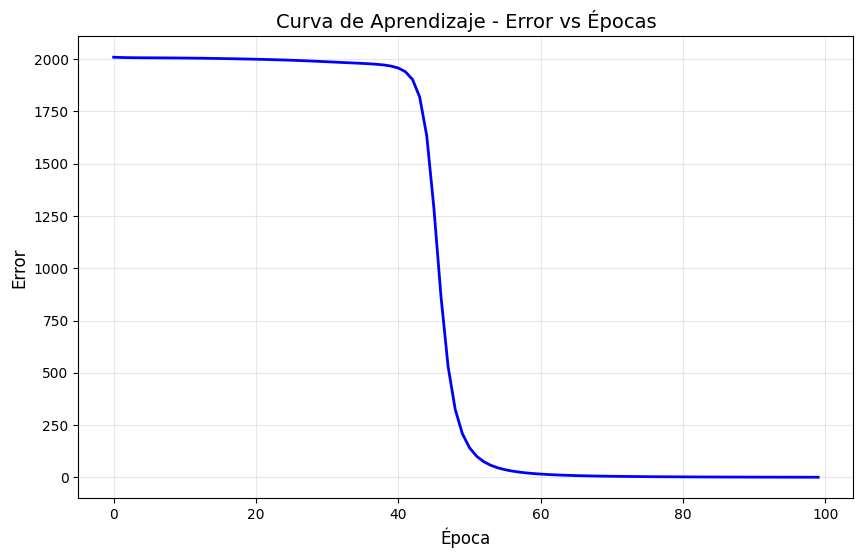

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Vamos a inspeccionar que superficie de decision se tiene

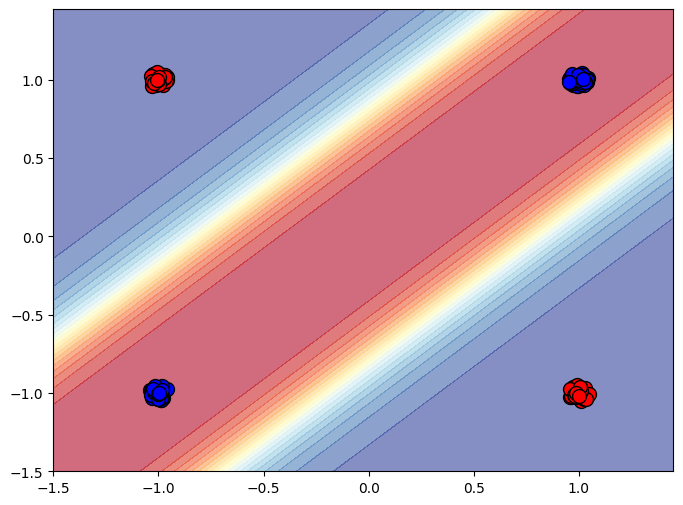

In [ ]:
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5

resolucion = 0.05 #delta x y delta y para hacer la maya

xx=np.arange(x_min, x_max, resolucion)
yy=np.arange(y_min, y_max, resolucion)

#creamos la malla 2d
X_malla, Y_malla = np.meshgrid(xx, yy)

#para cada punto de la malla predecimos su clase

puntos_aplanados = np.c_[X_malla.ravel(), Y_malla.ravel()] #los aplana para recorrerlos

predicciones = []
for punto in puntos_aplanados:
    punto_columna = punto.reshape(1,-1) #nuestra red espera una fila
    salida = model.transform(punto_columna)
    predicciones.append(salida.flatten()[0]) #retorna array nuestra salida


#convertimos a una malla
Z = np.array(predicciones).reshape(X_malla.shape)

plt.figure(figsize=(8, 6))
plt.contourf(X_malla, Y_malla, Z, levels=20, cmap='RdYlBu', alpha=0.6)
for i in range(len(X_test)):
    if y_test[i] == -1:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='blue', s=100, edgecolors='black')
    else:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='red', s=100, edgecolors='black')


